In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data/geoloc_compteurs.csv")

In [3]:
data

,Nom du com,N° Série,Latitude,Longitude,OSM_Line_i,Ancien N° Série
0,Compteur Vélo Tanneurs,XTH19101158,43.616209,3.874408,188609530,NaN
1,Compteur Piéton/Vélo Berracasa,X2H19070220,43.609699,3.896940,121403593,NaN
2,Compteur Vélo Lodève Celleneuve,Y2H20042633,43.614650,3.833600,734202564,NaN
3,Compteur Vélo Lavérune,X2H24042101,43.590700,3.813240,97705885,NaN
4,Compteur Vélo Vieille poste,ZLT25011699,43.615742,3.909632,676645909,NaN
5,Compteur Vélo Delmas 2,Y2H20063164,43.626698,3.895629,105575465,Y2H20063164
6,Compteur Vélo Delmas 1,ZLT26063736,43.626698,3.895629,105575465,Y2H20063163
7,Compteur Vélo Gerhardt 1,Y2H20063162,43.613884,3.868467,23231541,NaN
8,Compteur Vélo Lattes 2,Y2H20042634,43.579260,3.933270,25871951,NaN
9,Compteur Vélo Lattes 1,Y2H20042635,43.578830,3.933240,137058167,NaN


In [4]:
data.shape

(60, 6)

 Сколько счётчиков активно сейчас и где они стоят. Публикация набора упоминала восемь —
проверьте актуальное число, оно могло вырасти.

In [5]:
data["N° Série"].nunique()

60

In [6]:
import json

with open("data/eco_archives/MMM_EcoCompt_COM23070049_archive.json") as f:
    eco = [json.loads(line) for line in f if line.strip()]

eco_df = pd.DataFrame(eco)
eco_df["date"] = pd.to_datetime(eco_df["dateObserved"].str.split("/").str[0])
eco_df = eco_df.sort_values("date").reset_index(drop=True)
eco_df

,intensity,laneId,dateObserved,location,id,type,vehicleType,reversedLane,date
0,482.0,118234623,2026-06-04T00:00:00/2026-06-05T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606040000,TrafficFlowObserved,bicycle,False,2026-06-04
1,469.0,118234623,2026-06-05T00:00:00/2026-06-06T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606050000,TrafficFlowObserved,bicycle,False,2026-06-05
2,264.0,118234623,2026-06-06T00:00:00/2026-06-07T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606060000,TrafficFlowObserved,bicycle,False,2026-06-06
3,267.0,118234623,2026-06-07T00:00:00/2026-06-08T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606070000,TrafficFlowObserved,bicycle,False,2026-06-07
4,582.0,118234623,2026-06-08T00:00:00/2026-06-09T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606080000,TrafficFlowObserved,bicycle,False,2026-06-08
...,...,...,...,...,...,...,...,...,...
58,218.0,118234623,2026-08-01T00:00:00/2026-08-02T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608010000,TrafficFlowObserved,bicycle,False,2026-08-01
59,242.0,118234623,2026-08-02T00:00:00/2026-08-03T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608020000,TrafficFlowObserved,bicycle,False,2026-08-02
60,341.0,118234623,2026-08-03T00:00:00/2026-08-04T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608030000,TrafficFlowObserved,bicycle,False,2026-08-03
61,352.0,118234623,2026-08-04T00:00:00/2026-08-05T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608040000,TrafficFlowObserved,bicycle,False,2026-08-04


In [7]:
# Извлекаем серийный номер из id: MMM_EcoCompt_<serial>_<datetime>
eco_df["serial"] = eco_df["id"].str.extract(r"MMM_EcoCompt_(.+)_\d{12}")

# Справочник координат из geoloc_compteurs
coords_ref = data.set_index("N° Série")[["Latitude", "Longitude"]]

def get_coords(row):
    loc = row["location"]["coordinates"]  # [lon, lat]
    if loc[0] is None or loc[1] is None:
        ref = coords_ref.loc[row["serial"]] if row["serial"] in coords_ref.index else None
        if ref is not None:
            return ref["Longitude"], ref["Latitude"]
        return None, None
    return loc[0], loc[1]

eco_df[["lon", "lat"]] = eco_df.apply(get_coords, axis=1, result_type="expand")

In [8]:
eco_df

,intensity,laneId,dateObserved,location,id,type,vehicleType,reversedLane,date,serial,lon,lat
0,482.0,118234623,2026-06-04T00:00:00/2026-06-05T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606040000,TrafficFlowObserved,bicycle,False,2026-06-04,COM23070049,3.883689,43.596989
1,469.0,118234623,2026-06-05T00:00:00/2026-06-06T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606050000,TrafficFlowObserved,bicycle,False,2026-06-05,COM23070049,3.883689,43.596989
2,264.0,118234623,2026-06-06T00:00:00/2026-06-07T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606060000,TrafficFlowObserved,bicycle,False,2026-06-06,COM23070049,3.883689,43.596989
3,267.0,118234623,2026-06-07T00:00:00/2026-06-08T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606070000,TrafficFlowObserved,bicycle,False,2026-06-07,COM23070049,3.883689,43.596989
4,582.0,118234623,2026-06-08T00:00:00/2026-06-09T00:00:00,"{'coordinates': [3.883688825499899, 43.5969892...",MMM_EcoCompt_COM23070049_202606080000,TrafficFlowObserved,bicycle,False,2026-06-08,COM23070049,3.883689,43.596989
...,...,...,...,...,...,...,...,...,...,...,...,...
58,218.0,118234623,2026-08-01T00:00:00/2026-08-02T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608010000,TrafficFlowObserved,bicycle,False,2026-08-01,COM23070049,3.883731,43.596997
59,242.0,118234623,2026-08-02T00:00:00/2026-08-03T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608020000,TrafficFlowObserved,bicycle,False,2026-08-02,COM23070049,3.883731,43.596997
60,341.0,118234623,2026-08-03T00:00:00/2026-08-04T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608030000,TrafficFlowObserved,bicycle,False,2026-08-03,COM23070049,3.883731,43.596997
61,352.0,118234623,2026-08-04T00:00:00/2026-08-05T00:00:00,"{'coordinates': [3.8837306666666667, 43.596997...",MMM_EcoCompt_COM23070049_202608040000,TrafficFlowObserved,bicycle,False,2026-08-04,COM23070049,3.883731,43.596997


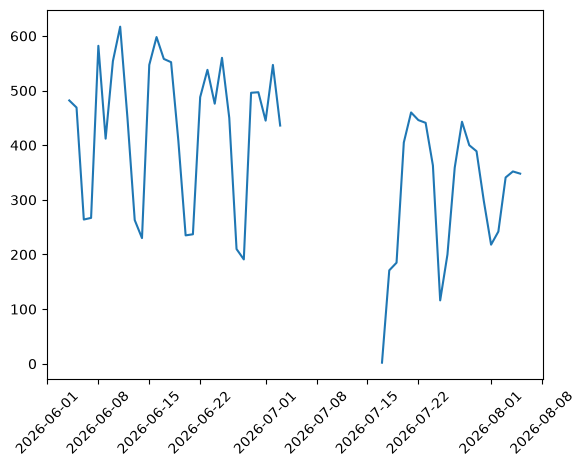

In [9]:
plt.figure()
plt.plot(eco_df["date"], eco_df["intensity"])
plt.xticks(rotation=45)
plt.show()

In [10]:
import requests
import time
from tqdm.notebook import tqdm

HEADERS = {"User-Agent": "matsim-analysis/1.0"}

def reverse_geocode_commune(lat, lon):
    r = requests.get(
        "https://nominatim.openstreetmap.org/reverse",
        params={"lat": lat, "lon": lon, "format": "json"},
        headers=HEADERS,
        timeout=10,
    )
    addr = r.json().get("address", {})
    return addr.get("city") or addr.get("town") or addr.get("village") or addr.get("municipality")

communes = []
for _, row in tqdm(data.iterrows(), total=len(data), desc="Reverse geocoding"):
    communes.append(reverse_geocode_commune(row["Latitude"], row["Longitude"]))
    time.sleep(1)

data["commune"] = communes

Reverse geocoding:   0%|          | 0/60 [00:00<?, ?it/s]

In [11]:
import folium

palette = [
    "#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed",
    "#db2777", "#0891b2", "#65a30d", "#ea580c", "#6366f1",
]
communes_unique = data["commune"].dropna().unique()
color_map = {c: palette[i % len(palette)] for i, c in enumerate(communes_unique)}

m = folium.Map(
    location=[data["Latitude"].mean(), data["Longitude"].mean()],
    zoom_start=12,
    tiles="CartoDB positron",
)

for _, row in data.iterrows():
    color = color_map.get(row["commune"], "#888888")
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=7,
        color=color,
        fill=True,
        fill_opacity=0.85,
        tooltip=f"{row['Nom du com']} ({row['commune']})",
        popup=f"{row['Nom du com']}<br>Série: {row['N° Série']}<br>Commune: {row['commune']}",
    ).add_to(m)

# Легенда
legend_html = "<div style='position:fixed;bottom:30px;left:30px;background:white;padding:10px;border-radius:8px;font-size:13px;z-index:9999;box-shadow:0 2px 6px rgba(0,0,0,.3)'>"
for commune, color in color_map.items():
    legend_html += f"<div><span style='display:inline-block;width:12px;height:12px;border-radius:50%;background:{color};margin-right:6px'></span>{commune}</div>"
legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

m

In [12]:
import json
from pathlib import Path
import pandas as pd

ARCHIVE_DIR = Path("data/eco_archives")
coords_ref = data.set_index("N° Série")[["Latitude", "Longitude"]]

_decoder = json.JSONDecoder()

def _parse_records(line: str) -> list:
    """Вычитывает все JSON-объекты из строки, включая склеенные без разделителя."""
    records = []
    idx = 0
    line = line.strip()
    while idx < len(line):
        # Пропускаем пробелы между объектами
        while idx < len(line) and line[idx] in " \t\r\n":
            idx += 1
        if idx >= len(line):
            break
        try:
            obj, end = _decoder.raw_decode(line, idx)
            records.append(obj)
            idx = end
        except json.JSONDecodeError:
            break
    return records


def load_eco_archive(path: Path) -> pd.DataFrame:
    """
    Читает NDJSON-архив из eco_archives.
    Обрабатывает:
      - пустые файлы (0 байт)
      - пустые/пробельные строки
      - строки с несколькими склеенными JSON-объектами (}{)
      - null-координаты → подставляет из geoloc_compteurs.csv
    """
    path = Path(path)
    serial = path.stem.replace("MMM_EcoCompt_", "").replace("_archive", "")

    if path.stat().st_size == 0:
        return pd.DataFrame()

    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            records.extend(_parse_records(line))

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)

    df["date"] = pd.to_datetime(
        df["dateObserved"].str.split("/").str[0]
    ).dt.date

    ref_lon = coords_ref.loc[serial, "Longitude"] if serial in coords_ref.index else None
    ref_lat = coords_ref.loc[serial, "Latitude"]  if serial in coords_ref.index else None

    def _extract_coords(loc):
        lon, lat = loc["coordinates"]
        if lon is None or lat is None:
            return ref_lon, ref_lat
        return lon, lat

    df[["lon", "lat"]] = df["location"].apply(_extract_coords).apply(pd.Series)
    df["serial"] = serial

    return df.drop(columns=["location", "dateObserved"]).sort_values("date").reset_index(drop=True)


# --- Тест на всех 60 файлах ---
results = []
for path in sorted(ARCHIVE_DIR.glob("*.json")):
    serial = path.stem.replace("MMM_EcoCompt_", "").replace("_archive", "")
    df = load_eco_archive(path)
    results.append({
        "serial":     serial,
        "rows":       len(df),
        "empty_file": len(df) == 0,
        "null_coords": int(df[["lon", "lat"]].isnull().any(axis=1).sum()) if len(df) else 0,
        "date_min":   df["date"].min() if len(df) else None,
        "date_max":   df["date"].max() if len(df) else None,
    })

summary = pd.DataFrame(results)
summary

,serial,rows,empty_file,null_coords,date_min,date_max
0,COM23070049,63,False,0,2026-06-04,2026-08-05
1,COM23120110,391,False,0,2025-07-02,2026-08-10
2,COM23120112,390,False,0,2025-07-02,2026-08-10
3,COM23120113,391,False,0,2025-07-02,2026-08-10
4,COM23120114,391,False,0,2025-07-02,2026-08-10
5,COM23120117,392,False,0,2025-07-02,2026-08-10
6,COM24010119,191,False,0,2026-01-13,2026-07-21
7,COM24010120,390,False,0,2025-07-02,2026-08-10
8,COM24010121,213,False,0,2026-01-13,2026-08-10
9,X2H19070220,2048,False,0,2020-12-17,2026-08-10


In [13]:
from pathlib import Path
import json
import pandas as pd

ARCHIVE_DIR = Path("data/eco_archives")
_decoder = json.JSONDecoder()

def _parse_records(line):
    records, idx = [], 0
    line = line.strip()
    while idx < len(line):
        while idx < len(line) and line[idx] in " \t\r\n":
            idx += 1
        if idx >= len(line):
            break
        try:
            obj, end = _decoder.raw_decode(line, idx)
            records.append(obj); idx = end
        except json.JSONDecodeError:
            break
    return records

def _date_range(path):
    """Возвращает (date_min, date_max, n_days) для одного архива."""
    path = Path(path)
    if path.stat().st_size == 0:
        return None, None, 0
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            records.extend(_parse_records(line))
    if not records:
        return None, None, 0
    dates = sorted({r["dateObserved"].split("/")[0][:10] for r in records})
    return dates[0], dates[-1], len(dates)

# --- Диапазоны по всем файлам ---
ranges = {}
for path in sorted(ARCHIVE_DIR.glob("*.json")):
    serial = path.stem.replace("MMM_EcoCompt_", "").replace("_archive", "")
    ranges[serial] = _date_range(path)

# --- Связи замены оборудования из geoloc_compteurs ---
# Ancien N° Série: текущий serial заменил старый
replacements = (
    data[data["Ancien N° Série"].notna()]
    [["N° Série", "Nom du com", "Ancien N° Série"]]
    .rename(columns={"N° Série": "new_serial", "Ancien N° Série": "old_serial"})
)

# --- Сводная таблица ---
rows = []
seen_as_old = set(replacements["old_serial"])

for serial, (dmin, dmax, n) in sorted(ranges.items()):
    is_replacement = serial in replacements["new_serial"].values
    old_serial = replacements.loc[replacements["new_serial"] == serial, "old_serial"].values
    old_serial = old_serial[0] if len(old_serial) else None

    # Если у старого серийного есть свой диапазон — объединяем
    if old_serial and old_serial in ranges and ranges[old_serial][0]:
        old_dmin, old_dmax, old_n = ranges[old_serial]
        combined_start = min(old_dmin, dmin) if dmin else old_dmin
        combined_end   = max(old_dmax, dmax) if dmax else old_dmax
    else:
        combined_start = dmin
        combined_end   = dmax

    name = data.loc[data["N° Série"] == serial, "Nom du com"].values
    name = name[0] if len(name) else "—"

    rows.append({
        "serial":           serial,
        "Nom du com":       name,
        "old_serial":       old_serial,
        "date_min":         dmin,
        "date_max":         dmax,
        "n_days":           n,
        "combined_start":   combined_start,
        "combined_end":     combined_end,
        "empty":            n == 0,
    })

timeline = (
    pd.DataFrame(rows)
    .sort_values(["empty", "combined_start"], ascending=[True, True])
    .reset_index(drop=True)
)
timeline

,serial,Nom du com,old_serial,date_min,date_max,n_days,combined_start,combined_end,empty
0,X2H20104132,Compteur Vélo Méric,NaN,2020-11-12,2026-07-28,2016,2020-11-12,2026-07-28,False
1,X2H19070220,Compteur Piéton/Vélo Berracasa,NaN,2020-12-17,2026-08-10,1986,2020-12-17,2026-08-10,False
2,XTH19101158,Compteur Vélo Tanneurs,NaN,2020-12-17,2026-08-10,1993,2020-12-17,2026-08-10,False
3,X2H21070341,Compteur Vélo Père Soulas 1,NaN,2021-12-17,2026-08-01,1600,2021-12-17,2026-08-01,False
4,X2H21070343,Compteur Vélo M17 Montferrier 1,NaN,2021-12-17,2026-08-10,1609,2021-12-17,2026-08-10,False
5,X2H21070344,Compteur Vélo Figuerolles,NaN,2021-12-17,2026-07-14,1603,2021-12-17,2026-07-14,False
6,X2H21070345,Compteur Piéton/vélo Pavelet,NaN,2021-12-17,2026-08-10,1630,2021-12-17,2026-08-10,False
7,X2H21070346,Compteur Vélo M21 Jacou,NaN,2021-12-17,2026-08-10,1630,2021-12-17,2026-08-10,False
8,X2H21070347,Compteur Vélo N17 Montferrier 2,NaN,2021-12-17,2026-02-27,1466,2021-12-17,2026-02-27,False
9,X2H21070348,Compteur Vélo Einstein,NaN,2021-12-17,2025-09-22,1375,2021-12-17,2025-09-22,False


In [16]:
timeline[["serial", "combined_start", "combined_end"]]

,serial,combined_start,combined_end
0,X2H20104132,2020-11-12,2026-07-28
1,X2H19070220,2020-12-17,2026-08-10
2,XTH19101158,2020-12-17,2026-08-10
3,X2H21070341,2021-12-17,2026-08-01
4,X2H21070343,2021-12-17,2026-08-10
5,X2H21070344,2021-12-17,2026-07-14
6,X2H21070345,2021-12-17,2026-08-10
7,X2H21070346,2021-12-17,2026-08-10
8,X2H21070347,2021-12-17,2026-02-27
9,X2H21070348,2021-12-17,2025-09-22


In [14]:
from datetime import date, timedelta

WINDOW_START = date(2023, 6, 1)
WINDOW_END   = date(2024, 6, 1)
MAX_GAP_DAYS = 14  # максимально допустимый пропуск внутри окна

def check_coverage(path: Path) -> dict:
    path = Path(path)
    serial = path.stem.replace("MMM_EcoCompt_", "").replace("_archive", "")

    if path.stat().st_size == 0:
        return {"serial": serial, "covers_window": False, "max_gap": None, "n_days_in_window": 0, "reason": "пустой файл"}

    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            records.extend(_parse_records(line))

    if not records:
        return {"serial": serial, "covers_window": False, "max_gap": None, "n_days_in_window": 0, "reason": "нет записей"}

    dates = sorted({
        date.fromisoformat(r["dateObserved"].split("/")[0][:10])
        for r in records
    })

    date_min, date_max = dates[0], dates[-1]

    # Диапазон не покрывает окно
    if date_min > WINDOW_START:
        return {"serial": serial, "covers_window": False, "max_gap": None,
                "n_days_in_window": 0, "reason": f"начало {date_min} > {WINDOW_START}"}
    if date_max < WINDOW_END:
        return {"serial": serial, "covers_window": False, "max_gap": None,
                "n_days_in_window": 0, "reason": f"конец {date_max} < {WINDOW_END}"}

    # Даты внутри окна
    dates_in_window = sorted(d for d in dates if WINDOW_START <= d <= WINDOW_END)
    n_days = len(dates_in_window)

    # Максимальный пропуск внутри окна
    max_gap = 0
    if len(dates_in_window) > 1:
        gaps = [(dates_in_window[i+1] - dates_in_window[i]).days
                for i in range(len(dates_in_window) - 1)]
        max_gap = max(gaps)

    # Проверяем также пропуск от WINDOW_START до первой даты в окне
    gap_at_start = (dates_in_window[0] - WINDOW_START).days if dates_in_window else 999

    ok = max_gap <= MAX_GAP_DAYS and gap_at_start <= MAX_GAP_DAYS
    reason = "OK" if ok else f"макс. пропуск {max(max_gap, gap_at_start)} дн."

    return {
        "serial":           serial,
        "covers_window":    ok,
        "max_gap":          max(max_gap, gap_at_start),
        "n_days_in_window": n_days,
        "reason":           reason,
    }


coverage = pd.DataFrame([
    check_coverage(path)
    for path in sorted(ARCHIVE_DIR.glob("*.json"))
]).sort_values(["covers_window", "max_gap"], ascending=[False, True]).reset_index(drop=True)

n_ok = coverage["covers_window"].sum()
print(f"Счётчиков с непрерывными данными ±6 мес. от дек. 2023: {n_ok} из {len(coverage)}")
print(f"(окно {WINDOW_START} — {WINDOW_END}, макс. допустимый пропуск {MAX_GAP_DAYS} дн.)\n")
coverage

Счётчиков с непрерывными данными ±6 мес. от дек. 2023: 32 из 60
(окно 2023-06-01 — 2024-06-01, макс. допустимый пропуск 14 дн.)



,serial,covers_window,max_gap,n_days_in_window,reason
0,X2H19070220,True,1.0,367,OK
1,X2H20104132,True,1.0,367,OK
2,X2H21070341,True,1.0,367,OK
3,X2H21070343,True,1.0,367,OK
4,X2H21070344,True,1.0,367,OK
5,X2H21070345,True,1.0,367,OK
6,X2H21070346,True,1.0,367,OK
7,X2H21070347,True,1.0,367,OK
8,X2H21070348,True,1.0,367,OK
9,X2H21070349,True,1.0,367,OK


In [15]:
coverage[coverage["reason"] == "OK"].shape

(32, 5)